In [290]:
# imports
import pandas as pd
from pathlib import Path

In [291]:
root = Path("../data")
W_files = []
M_files = []

for file in root.rglob("*.csv"):
    name = file.name.capitalize()

    if name.startswith("W"):
        W_files.append(file)
    elif name.startswith("M"):
        M_files.append(file)

print(f"Women: {len(W_files)}, Men: {len(M_files)}")



Women: 14, Men: 17


In [292]:
# Group 1: Identity tables(joins keys, not features)
identity_table_file = ["Mteams", "MSeasons", "MTeamConferences", "Cities"]
# Group 2: Game Results
game_results = [
    "MRegularSeasonCompactResults", "MRegularSeasonDetailedResults", 
    "MNCAATourneyCompactResults", "MNCAATourneyDetailedResults",
]
# Group 3: Tournament Structure
tournament_structure = ["MNCAATourneySeeds", "MNCAATourneySlots", "MNCAATourneySeedRoundSlots",]
# Group 4: External Rankings
external_ranking = ["MMasseyOrdinals"]
# Group 5: Geography/Misc
geography = ["MGameCities", "MTeamCoaches", "MConferenceTourneyGames", "Cities"]

In [293]:
# Group 2 - Game Results
tourney_results = pd.read_csv('../data/MNCAATourneyCompactResults.csv')
regular_season_detailed = pd.read_csv('../data/MRegularSeasonDetailedResults.csv')

# Group 3 - Tournament Structure
tourney_seeds = pd.read_csv('../data/MNCAATourneySeeds.csv')

# Group 4 - External Rankings
massey = pd.read_csv('../data/MMasseyOrdinals.csv')

tournament_season_detailed = pd.read_csv('../data/MNCAATourneyDetailedResults.csv')


print("tourney_results:", tourney_results.shape)
print("regular_season_detailed:", regular_season_detailed.shape)
print("tourney_seeds:", tourney_seeds.shape)
print("massey:", massey.shape)
print(tournament_season_detailed.shape)
print(tournament_season_detailed.head())

tourney_results: (2585, 8)
regular_season_detailed: (124529, 34)
tourney_seeds: (2694, 3)
massey: (5865001, 5)
(1449, 34)
   Season  DayNum  WTeamID  WScore  LTeamID  LScore WLoc  NumOT  WFGM  WFGA  \
0    2003     134     1421      92     1411      84    N      1    32    69   
1    2003     136     1112      80     1436      51    N      0    31    66   
2    2003     136     1113      84     1272      71    N      0    31    59   
3    2003     136     1141      79     1166      73    N      0    29    53   
4    2003     136     1143      76     1301      74    N      1    27    64   

   ...  LFGA3  LFTM  LFTA  LOR  LDR  LAst  LTO  LStl  LBlk  LPF  
0  ...     31    14    31   17   28    16   15     5     0   22  
1  ...     16     7     7    8   26    12   17    10     3   15  
2  ...     28    14    21   20   22    11   12     2     5   18  
3  ...     17    12    17   14   17    20   21     6     6   21  
4  ...     21    15    20   10   26    16   14     5     8   19  

[5 row

In [294]:
# Season range
TRAIN_START = 2010
VALID_SEASON = 2025
TEST_SEASON = 2026

# Filter all files to 2010 onwards
tourney_results = tourney_results[tourney_results['Season'] >= TRAIN_START].reset_index(drop=True)
regular_season_detailed = regular_season_detailed[regular_season_detailed['Season'] >= TRAIN_START].reset_index(drop=True)
tourney_seeds = tourney_seeds[tourney_seeds['Season'] >= TRAIN_START].reset_index(drop=True)

# Filter Massey — final pre-tournament ranking + 2 systems only
systems_to_keep = ['MOR', 'POM']
massey_filtered = massey[
    (massey['RankingDayNum'] == 133) &
    (massey['SystemName'].isin(systems_to_keep)) &
    (massey['Season'] >= TRAIN_START)
].reset_index(drop=True)

print("tourney_results:", tourney_results.shape)
print("regular_season_detailed:", regular_season_detailed.shape)
print("tourney_seeds:", tourney_seeds.shape)
print("massey_filtered:", massey_filtered.shape)

tourney_results: (1001, 8)
regular_season_detailed: (90455, 34)
tourney_seeds: (1085, 3)
massey_filtered: (11302, 5)


In [295]:
print(massey_filtered.head())
print(tourney_results.head())
print(regular_season_detailed.head())
print("Tourney Seed \n")
print(tourney_seeds.head())

   Season  RankingDayNum SystemName  TeamID  OrdinalRank
0    2010            133        MOR    1102          227
1    2010            133        MOR    1103          118
2    2010            133        MOR    1104           57
3    2010            133        MOR    1105          337
4    2010            133        MOR    1106          303
   Season  DayNum  WTeamID  WScore  LTeamID  LScore WLoc  NumOT
0    2010     134     1115      61     1457      44    N      0
1    2010     136     1124      68     1358      59    N      0
2    2010     136     1139      77     1431      59    N      0
3    2010     136     1140      99     1196      92    N      2
4    2010     136     1242      90     1250      74    N      0
   Season  DayNum  WTeamID  WScore  LTeamID  LScore WLoc  NumOT  WFGM  WFGA  \
0    2010       7     1143      75     1293      70    H      0    24    52   
1    2010       7     1314      88     1198      72    H      0    34    61   
2    2010       7     1326     100   

In [296]:
# Extract numeric seed from string like 'W01', 'X16', 'Y04'
tourney_seeds['SeedNum'] = tourney_seeds['Seed'].str.extract(r'(\d+)').astype(int)

# Drop original Seed string column
tourney_seeds = tourney_seeds.drop(columns=['Seed'])

print(tourney_seeds.head(10))

   Season  TeamID  SeedNum
0    2010    1246        1
1    2010    1452        2
2    2010    1307        3
3    2010    1458        4
4    2010    1396        5
5    2010    1266        6
6    2010    1155        7
7    2010    1400        8
8    2010    1448        9
9    2010    1281       10


In [297]:
massey_wide = massey_filtered.pivot_table(
    index=['Season', 'TeamID'],
    columns='SystemName',
    values='OrdinalRank'
).reset_index()
massey_wide = massey_wide.rename(columns={
    'MOR': 'MOR_Rank',
    'POM': 'POM_Rank'
})


print(massey_wide.shape)
print(massey_wide.head())
print(massey_wide.isnull().sum())

(5651, 4)
SystemName  Season  TeamID  MOR_Rank  POM_Rank
0             2010    1102     227.0     246.0
1             2010    1103     118.0     119.0
2             2010    1104      57.0      64.0
3             2010    1105     337.0     336.0
4             2010    1106     303.0     302.0
SystemName
Season      0
TeamID      0
MOR_Rank    0
POM_Rank    0
dtype: int64


In [298]:
win_rows = regular_season_detailed[[
    'Season', 'WTeamID', 'WScore', 'LScore',
    'WFGM', 'WFGA', 'WFGM3', 'WFTM', 'WFTA',
    'WOR', 'WDR', 'WTO'
]].rename(columns={
    'WTeamID': 'TeamID',
    'WScore': 'PointsFor',
    'LScore' : 'PointsAgainst',
    'WFGM': 'FGM', 'WFGA': 'FGA', 'WFGM3':'FGM3',
    'WFTM':'FTM', 'WFTA':'FTA',
    'WOR':'OR', 'WDR': 'DR', 'WTO':'TO'
})
win_rows['Win']=1

# Loser rows
loss_rows = regular_season_detailed[[
    'Season', 'LTeamID', 'LScore', 'WScore',
    'LFGM', 'LFGA', 'LFGM3', 'LFTM', 'LFTA',
    'LOR', 'LDR', 'LTO'
]].rename(columns={
    'LTeamID': 'TeamID',
    'LScore': 'PointsFor',
    'WScore': 'PointsAgainst',
    'LFGM': 'FGM', 'LFGA': 'FGA', 'LFGM3': 'FGM3',
    'LFTM': 'FTM', 'LFTA': 'FTA',
    'LOR': 'OR', 'LDR': 'DR', 'LTO': 'TO'
})
loss_rows['Win'] = 0


# combine
team_games =pd.concat([win_rows, loss_rows], ignore_index=True)

print(team_games.shape)
print(team_games.head())

(180910, 13)
   Season  TeamID  PointsFor  PointsAgainst  FGM  FGA  FGM3  FTM  FTA  OR  DR  \
0    2010    1143         75             70   24   52     5   22   32  13  19   
1    2010    1314         88             72   34   61     4   16   19  12  32   
2    2010    1326        100             60   39   73    14    8   12  13  34   
3    2010    1393         75             43   29   60     2   15   31  14  32   
4    2010    1143         95             61   29   61     7   30   35  15  30   

   TO  Win  
0  12    1  
1  26    1  
2   6    1  
3  21    1  
4  10    1  


In [299]:
team_season_stats = team_games.groupby(['Season', 'TeamID'])[['Win', 'PointsFor', 'PointsAgainst']].agg('mean').reset_index()
team_season_stats['point_differential'] = team_season_stats['PointsFor'] - team_season_stats['PointsAgainst']
team_season_stats = team_season_stats.drop(columns={'PointsFor', 'PointsAgainst'})
team_season_stats

,Season,TeamID,Win,point_differential
0,2010,1102,0.275862,-7.344828
1,2010,1103,0.696970,4.575758
2,2010,1104,0.531250,3.718750
3,2010,1105,0.347826,-6.478261
4,2010,1106,0.464286,-2.392857
...,...,...,...,...
5999,2026,1477,0.300000,-8.966667
6000,2026,1478,0.451613,-1.580645
6001,2026,1479,0.468750,-0.406250
6002,2026,1480,0.433333,-5.166667


In [300]:
four_factors = team_games.groupby(['Season', 'TeamID'])[['FGM', 'FGM3', 'FGA', 'FTA', 'TO', 'OR', 'DR', 'FTM']].agg('sum').reset_index()
four_factors['eFG%'] = (four_factors['FGM'] + 0.5*four_factors['FGM3']) / four_factors['FGA']
four_factors['TO_rate'] = four_factors['TO'] / (four_factors['FGA'] + 0.44*four_factors['FTA'] + four_factors['TO'])
four_factors['OR_rate']= four_factors['OR'] / (four_factors['OR'] + four_factors['DR'])
four_factors['FT_rate'] = four_factors['FTM']/four_factors['FGA']
four_factors= four_factors.drop(columns={'FGM', 'FGA', 'FGM3', 'FTA', 'TO', 'OR', 'DR', 'FTM'})
four_factors

,Season,TeamID,eFG%,TO_rate,OR_rate,FT_rate
0,2010,1102,0.500378,0.195965,0.253886,0.219365
1,2010,1103,0.492639,0.169317,0.372171,0.247108
2,2010,1104,0.489688,0.165683,0.342806,0.242475
3,2010,1105,0.403802,0.186780,0.392421,0.308745
4,2010,1106,0.451936,0.201710,0.374374,0.293057
...,...,...,...,...,...,...
5999,2026,1477,0.492234,0.164856,0.253714,0.217443
6000,2026,1478,0.526520,0.163887,0.219414,0.283075
6001,2026,1479,0.494603,0.118072,0.257576,0.189423
6002,2026,1480,0.496025,0.130997,0.302817,0.205617


In [301]:
team_season_stats = team_season_stats.merge(four_factors, on=['Season', 'TeamID'], how='right')
team_season_stats

,Season,TeamID,Win,point_differential,eFG%,TO_rate,OR_rate,FT_rate
0,2010,1102,0.275862,-7.344828,0.500378,0.195965,0.253886,0.219365
1,2010,1103,0.696970,4.575758,0.492639,0.169317,0.372171,0.247108
2,2010,1104,0.531250,3.718750,0.489688,0.165683,0.342806,0.242475
3,2010,1105,0.347826,-6.478261,0.403802,0.186780,0.392421,0.308745
4,2010,1106,0.464286,-2.392857,0.451936,0.201710,0.374374,0.293057
...,...,...,...,...,...,...,...,...
5999,2026,1477,0.300000,-8.966667,0.492234,0.164856,0.253714,0.217443
6000,2026,1478,0.451613,-1.580645,0.526520,0.163887,0.219414,0.283075
6001,2026,1479,0.468750,-0.406250,0.494603,0.118072,0.257576,0.189423
6002,2026,1480,0.433333,-5.166667,0.496025,0.130997,0.302817,0.205617


In [302]:
print(team_season_stats.describe())

            Season       TeamID          Win  point_differential         eFG%  \
count  6004.000000  6004.000000  6004.000000         6004.000000  6004.000000   
mean   2018.080113  1286.445703     0.494337           -0.210589     0.498919   
std       4.908262   105.517666     0.186244            6.635642     0.031330   
min    2010.000000  1101.000000     0.000000          -33.222222     0.392276   
25%    2014.000000  1195.000000     0.360000           -4.658854     0.477871   
50%    2018.000000  1285.500000     0.500000           -0.166667     0.498693   
75%    2022.000000  1378.000000     0.625000            4.244318     0.519395   
max    2026.000000  1481.000000     1.000000           23.787879     0.610491   

           TO_rate      OR_rate      FT_rate  
count  6004.000000  6004.000000  6004.000000  
mean      0.161439     0.291197     0.245424  
std       0.020767     0.041629     0.039722  
min       0.098457     0.153110     0.126437  
25%       0.147532     0.263555    

In [303]:
print(tourney_seeds.head())
print(tourney_seeds.describe())
print(tourney_seeds.shape)

   Season  TeamID  SeedNum
0    2010    1246        1
1    2010    1452        2
2    2010    1307        3
3    2010    1458        4
4    2010    1396        5
            Season       TeamID      SeedNum
count  1085.000000  1085.000000  1085.000000
mean   2017.896774  1292.202765     8.789862
std       5.015515   104.413594     4.671308
min    2010.000000  1101.000000     1.000000
25%    2014.000000  1211.000000     5.000000
50%    2018.000000  1287.000000     9.000000
75%    2023.000000  1388.000000    13.000000
max    2026.000000  1474.000000    16.000000
(1085, 3)


In [304]:
team_season_stats = team_season_stats.merge(tourney_seeds, on=['Season', 'TeamID'], how='inner')
team_season_stats

,Season,TeamID,Win,point_differential,eFG%,TO_rate,OR_rate,FT_rate,SeedNum
0,2010,1115,0.531250,-0.281250,0.450030,0.209554,0.329518,0.325996,16
1,2010,1124,0.774194,10.161290,0.546238,0.176383,0.315526,0.273406,3
2,2010,1139,0.875000,10.062500,0.519925,0.169655,0.281637,0.356787,5
3,2010,1140,0.848485,16.939394,0.550926,0.141078,0.275410,0.300412,7
4,2010,1143,0.696970,9.575758,0.533696,0.150928,0.321186,0.266459,8
...,...,...,...,...,...,...,...,...,...
1080,2026,1438,0.852941,12.235294,0.546161,0.129606,0.314859,0.240039,3
1081,2026,1458,0.705882,7.088235,0.544634,0.107408,0.273394,0.250712,5
1082,2026,1460,0.656250,4.562500,0.544212,0.137428,0.291583,0.282958,14
1083,2026,1465,0.757576,5.454545,0.485948,0.143177,0.331929,0.259581,13


In [305]:
print(team_season_stats.columns.tolist())

['Season', 'TeamID', 'Win', 'point_differential', 'eFG%', 'TO_rate', 'OR_rate', 'FT_rate', 'SeedNum']


In [306]:
print(massey_wide.shape)
print(massey_wide.head())
print(massey_wide.describe())

(5651, 4)
SystemName  Season  TeamID  MOR_Rank  POM_Rank
0             2010    1102     227.0     246.0
1             2010    1103     118.0     119.0
2             2010    1104      57.0      64.0
3             2010    1105     337.0     336.0
4             2010    1106     303.0     302.0
SystemName       Season       TeamID     MOR_Rank     POM_Rank
count       5651.000000  5651.000000  5651.000000  5651.000000
mean        2017.960184  1286.528225   177.158025   177.158025
std            5.035028   105.558741   102.077127   102.077127
min         2010.000000  1101.000000     1.000000     1.000000
25%         2014.000000  1195.000000    89.000000    89.000000
50%         2018.000000  1286.000000   177.000000   177.000000
75%         2023.000000  1378.000000   265.000000   265.000000
max         2026.000000  1481.000000   365.000000   365.000000


In [307]:
tournament_teams = team_season_stats.merge(massey_wide, on=['Season', 'TeamID'], how='left')
print(tournament_teams.shape)
print(tournament_teams.isnull().sum())
print(tournament_teams.head())

(1085, 11)
Season                0
TeamID                0
Win                   0
point_differential    0
eFG%                  0
TO_rate               0
OR_rate               0
FT_rate               0
SeedNum               0
MOR_Rank              0
POM_Rank              0
dtype: int64
   Season  TeamID       Win  point_differential      eFG%   TO_rate   OR_rate  \
0    2010    1115  0.531250           -0.281250  0.450030  0.209554  0.329518   
1    2010    1124  0.774194           10.161290  0.546238  0.176383  0.315526   
2    2010    1139  0.875000           10.062500  0.519925  0.169655  0.281637   
3    2010    1140  0.848485           16.939394  0.550926  0.141078  0.275410   
4    2010    1143  0.696970            9.575758  0.533696  0.150928  0.321186   

    FT_rate  SeedNum  MOR_Rank  POM_Rank  
0  0.325996       16     269.0     238.0  
1  0.273406        3      11.0      12.0  
2  0.356787        5      24.0      26.0  
3  0.300412        7      14.0       7.0  
4  0.26645

In [308]:
tournament_teams = tournament_teams.sort_values(by=['TeamID'], ascending=[True])
tournament_teams

,Season,TeamID,Win,point_differential,eFG%,TO_rate,OR_rate,FT_rate,SeedNum,MOR_Rank,POM_Rank
609,2019,1101,0.793103,6.827586,0.524345,0.154810,0.283711,0.249688,15,169.0,145.0
677,2021,1101,0.826087,14.565217,0.529087,0.165216,0.296247,0.234168,14,77.0,86.0
1017,2026,1103,0.843750,12.375000,0.584623,0.129811,0.279452,0.218672,12,56.0,64.0
949,2025,1103,0.812500,8.062500,0.554337,0.140824,0.286099,0.200780,13,111.0,97.0
881,2024,1103,0.687500,5.531250,0.519380,0.143056,0.255588,0.243079,14,118.0,116.0
...,...,...,...,...,...,...,...,...,...,...,...
472,2016,1463,0.777778,10.962963,0.524455,0.168765,0.334559,0.280238,12,52.0,38.0
1015,2025,1463,0.750000,10.428571,0.547535,0.119552,0.261445,0.235915,13,68.0,73.0
1083,2026,1465,0.757576,5.454545,0.485948,0.143177,0.331929,0.259581,13,114.0,106.0
1016,2025,1471,0.875000,15.093750,0.554283,0.111797,0.234661,0.252046,12,45.0,37.0


In [309]:
tourney_win_rows = tournament_season_detailed[[
    'Season', 'WTeamID', 'WScore', 'LScore',
    'WFGM', 'WFGA', 'WFGM3', 'WFTM', 'WFTA',
    'WOR', 'WDR', 'WTO'
]].rename(columns={
    'WTeamID': 'TeamID',
    'WScore': 'PointsFor',
    'LScore' : 'PointsAgainst',
    'WFGM': 'FGM', 'WFGA': 'FGA', 'WFGM3':'FGM3',
    'WFTM':'FTM', 'WFTA':'FTA',
    'WOR':'OR', 'WDR': 'DR', 'WTO':'TO'
})
tourney_win_rows['Win']=1

# Loser rows
tourney_loss_rows = tournament_season_detailed[[
    'Season', 'LTeamID', 'LScore', 'WScore',
    'LFGM', 'LFGA', 'LFGM3', 'LFTM', 'LFTA',
    'LOR', 'LDR', 'LTO'
]].rename(columns={
    'LTeamID': 'TeamID',
    'LScore': 'PointsFor',
    'WScore': 'PointsAgainst',
    'LFGM': 'FGM', 'LFGA': 'FGA', 'LFGM3': 'FGM3',
    'LFTM': 'FTM', 'LFTA': 'FTA',
    'LOR': 'OR', 'LDR': 'DR', 'LTO': 'TO'
})
tourney_loss_rows['Win'] = 0


# combine
tourney_team_games =pd.concat([tourney_win_rows, tourney_loss_rows], ignore_index=True)

print(tourney_team_games.shape)
print(tourney_team_games.head())

(2898, 13)
   Season  TeamID  PointsFor  PointsAgainst  FGM  FGA  FGM3  FTM  FTA  OR  DR  \
0    2003    1421         92             84   32   69    11   17   26  14  30   
1    2003    1112         80             51   31   66     7   11   14  11  36   
2    2003    1113         84             71   31   59     6   16   22  10  27   
3    2003    1141         79             73   29   53     3   18   25  11  20   
4    2003    1143         76             74   27   64     7   15   23  18  20   

   TO  Win  
0  12    1  
1  16    1  
2   9    1  
3  18    1  
4  13    1  


In [310]:
past_season = []
for season in sorted(tourney_team_games['Season'].unique()):
    historical_data = tourney_team_games[tourney_team_games['Season']< season].copy()

    if historical_data.empty:
        continue
    historical_data['tourney_point_diff'] = historical_data['PointsFor'] - historical_data['PointsAgainst']

    agg = historical_data.groupby('TeamID')[['Win', 'tourney_point_diff']].mean().reset_index()
    
    agg['Season'] = season

    past_season.append(agg)

historical_tourney_stats = pd.concat(past_season, ignore_index=True)
historical_tourney_stats

,TeamID,Win,tourney_point_diff,Season
0,1104,0.000000,-5.000000,2004
1,1112,0.750000,11.000000,2004
2,1113,0.500000,-9.500000,2004
3,1120,0.666667,2.333333,2004
4,1122,0.000000,-22.000000,2004
...,...,...,...,...
4165,1459,0.166667,-3.666667,2025
4166,1460,0.250000,-13.250000,2025
4167,1461,0.000000,-12.500000,2025
4168,1462,0.605263,2.842105,2025


In [311]:
# join historical_tourney_stats onto tournament_teams on season and team id
tournament_teams = tournament_teams.merge(historical_tourney_stats, on=['Season', 'TeamID'], how='left')
print(tournament_teams.shape)
print(tournament_teams.isnull().sum())
print(tournament_teams.head())

(1085, 13)
Season                  0
TeamID                  0
Win_x                   0
point_differential      0
eFG%                    0
TO_rate                 0
OR_rate                 0
FT_rate                 0
SeedNum                 0
MOR_Rank                0
POM_Rank                0
Win_y                 159
tourney_point_diff    159
dtype: int64
   Season  TeamID     Win_x  point_differential      eFG%   TO_rate   OR_rate  \
0    2019    1101  0.793103            6.827586  0.524345  0.154810  0.283711   
1    2021    1101  0.826087           14.565217  0.529087  0.165216  0.296247   
2    2026    1103  0.843750           12.375000  0.584623  0.129811  0.279452   
3    2025    1103  0.812500            8.062500  0.554337  0.140824  0.286099   
4    2024    1103  0.687500            5.531250  0.519380  0.143056  0.255588   

    FT_rate  SeedNum  MOR_Rank  POM_Rank  Win_y  tourney_point_diff  
0  0.249688       15     169.0     145.0    NaN                 NaN  
1  0.234168

In [312]:
tournament_teams['has_tournament_history'] = (tournament_teams['Win_y'].notna()).astype(int)
tournament_teams = tournament_teams.rename(columns={
    'Win_x': 'regular_win_rate',
    'Win_y': 'tourney_win_rate'
})

In [313]:
cols = ["tourney_win_rate", "tourney_point_diff"]

tournament_teams = tournament_teams.sort_values("Season")

season_medians_hist = (
    tournament_teams.groupby('Season')[cols].median().expanding().median().shift()
)

for c in cols:
    tournament_teams[c] = tournament_teams[c].fillna(tournament_teams['Season'].map(season_medians_hist[c]))

tournament_teams[cols] = tournament_teams[cols].fillna(tournament_teams[cols].median())

In [314]:
tourney_results

,Season,DayNum,WTeamID,WScore,LTeamID,LScore,WLoc,NumOT
0,2010,134,1115,61,1457,44,N,0
1,2010,136,1124,68,1358,59,N,0
2,2010,136,1139,77,1431,59,N,0
3,2010,136,1140,99,1196,92,N,2
4,2010,136,1242,90,1250,74,N,0
...,...,...,...,...,...,...,...,...
996,2025,146,1120,70,1277,64,N,0
997,2025,146,1222,69,1397,50,N,0
998,2025,152,1196,79,1120,73,N,0
999,2025,152,1222,70,1181,67,N,0


In [315]:
tournament_teams.head()

,Season,TeamID,regular_win_rate,point_differential,eFG%,TO_rate,OR_rate,FT_rate,SeedNum,MOR_Rank,POM_Rank,tourney_win_rate,tourney_point_diff,has_tournament_history
1057,2010,1459,0.757576,7.151515,0.492386,0.157020,0.324786,0.300056,13,98.0,87.0,0.500000,-0.416667,0
860,2010,1400,0.727273,11.545455,0.513404,0.157203,0.354421,0.256582,8,30.0,17.0,0.666667,4.285714,1
842,2010,1396,0.852941,8.794118,0.488624,0.143748,0.297383,0.191005,5,35.0,18.0,0.000000,-10.000000,1
875,2010,1401,0.709677,6.483871,0.497598,0.158333,0.327418,0.330931,5,19.0,23.0,0.555556,1.666667,1
843,2010,1397,0.757576,8.696970,0.502307,0.162013,0.319307,0.240902,6,27.0,35.0,0.555556,3.444444,1


In [316]:
matchups = tourney_results.copy()
matchups['TeamID_Low'] = matchups[['WTeamID', 'LTeamID']].min(axis=1)
matchups['TeamID_High'] = matchups[['WTeamID', 'LTeamID']].max(axis=1)
matchups['Label'] = (matchups['WTeamID']==matchups['TeamID_Low']).astype(int)
matchups = matchups.drop(columns={'WTeamID', 'LTeamID', 'LScore', 'WLoc', 'WScore', 'NumOT', 'DayNum'})
matchups

,Season,TeamID_Low,TeamID_High,Label
0,2010,1115,1457,1
1,2010,1124,1358,1
2,2010,1139,1431,1
3,2010,1140,1196,1
4,2010,1242,1250,1
...,...,...,...,...
996,2025,1120,1277,1
997,2025,1222,1397,1
998,2025,1120,1196,0
999,2025,1181,1222,0


In [317]:
matchups = matchups.merge(tournament_teams, left_on=['TeamID_Low', 'Season'], right_on=['TeamID', 'Season'])
matchups

,Season,TeamID_Low,TeamID_High,Label,TeamID,regular_win_rate,point_differential,eFG%,TO_rate,OR_rate,FT_rate,SeedNum,MOR_Rank,POM_Rank,tourney_win_rate,tourney_point_diff,has_tournament_history
0,2010,1115,1457,1,1115,0.531250,-0.281250,0.450030,0.209554,0.329518,0.325996,16,269.0,238.0,0.500000,-0.416667,0
1,2010,1124,1358,1,1124,0.774194,10.161290,0.546238,0.176383,0.315526,0.273406,3,11.0,12.0,0.000000,-11.000000,1
2,2010,1139,1431,1,1139,0.875000,10.062500,0.519925,0.169655,0.281637,0.356787,5,24.0,26.0,0.555556,1.666667,1
3,2010,1140,1196,1,1140,0.848485,16.939394,0.550926,0.141078,0.275410,0.300412,7,14.0,7.0,0.000000,-6.000000,1
4,2010,1242,1250,1,1242,0.941176,17.970588,0.550553,0.157505,0.319303,0.297284,1,1.0,2.0,0.760000,10.960000,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
996,2025,1120,1277,1,1120,0.848485,14.242424,0.557115,0.112015,0.298401,0.248154,1,4.0,4.0,0.600000,0.466667,1
997,2025,1222,1397,1,1222,0.882353,15.735294,0.526763,0.116411,0.327338,0.208604,1,3.0,3.0,0.666667,7.476190,1
998,2025,1120,1196,0,1120,0.848485,14.242424,0.557115,0.112015,0.298401,0.248154,1,4.0,4.0,0.600000,0.466667,1
999,2025,1181,1222,0,1181,0.911765,20.794118,0.573632,0.120071,0.277049,0.251741,1,1.0,1.0,0.723077,8.123077,1


In [318]:
matchups = matchups.drop(columns={'TeamID'})
matchups = matchups.rename(columns={
    'point_differential': 'point_differential_low',
    'eFG%': 'eFG%_low',
    'TO_rate': 'TO_rate_low',
    'OR_rate': 'OR_rate_low',
    'FT_rate': 'FT_rate_low',
    'SeedNum': 'SeedNum_low',
    'MOR_Rank': 'MOR_Rank_low',
    'POM_Rank': 'POM_Rank_low',
    "regular_win_rate" : 'regular_win_rate_low',
    'tourney_win_rate' : 'tourney_win_rate_low',
    'tourney_point_diff': 'tourney_point_diff_low',
    'has_tournament_history': 'has_tournament_history_low'
})
print(matchups.columns.tolist())


['Season', 'TeamID_Low', 'TeamID_High', 'Label', 'regular_win_rate_low', 'point_differential_low', 'eFG%_low', 'TO_rate_low', 'OR_rate_low', 'FT_rate_low', 'SeedNum_low', 'MOR_Rank_low', 'POM_Rank_low', 'tourney_win_rate_low', 'tourney_point_diff_low', 'has_tournament_history_low']


In [319]:
matchups.head()

,Season,TeamID_Low,TeamID_High,Label,regular_win_rate_low,point_differential_low,eFG%_low,TO_rate_low,OR_rate_low,FT_rate_low,SeedNum_low,MOR_Rank_low,POM_Rank_low,tourney_win_rate_low,tourney_point_diff_low,has_tournament_history_low
0,2010,1115,1457,1,0.531250,-0.281250,0.450030,0.209554,0.329518,0.325996,16,269.0,238.0,0.500000,-0.416667,0
1,2010,1124,1358,1,0.774194,10.161290,0.546238,0.176383,0.315526,0.273406,3,11.0,12.0,0.000000,-11.000000,1
2,2010,1139,1431,1,0.875000,10.062500,0.519925,0.169655,0.281637,0.356787,5,24.0,26.0,0.555556,1.666667,1
3,2010,1140,1196,1,0.848485,16.939394,0.550926,0.141078,0.275410,0.300412,7,14.0,7.0,0.000000,-6.000000,1
4,2010,1242,1250,1,0.941176,17.970588,0.550553,0.157505,0.319303,0.297284,1,1.0,2.0,0.760000,10.960000,1


In [320]:
matchups = matchups.merge(tournament_teams, left_on=['TeamID_High', 'Season'], right_on=['TeamID', 'Season'])
matchups = matchups.drop(columns={'TeamID'})
matchups = matchups.rename(columns={
    'point_differential': 'point_differential_high',
    'eFG%': 'eFG%_high',
    'TO_rate': 'TO_rate_high',
    'OR_rate': 'OR_rate_high',
    'FT_rate': 'FT_rate_high',
    'SeedNum': 'SeedNum_high',
    'MOR_Rank': 'MOR_Rank_high',
    'POM_Rank': 'POM_Rank_high',
    "regular_win_rate" : 'regular_win_rate_high',
    'tourney_win_rate' : 'tourney_win_rate_high',
    'tourney_point_diff': 'tourney_point_diff_high',
    'has_tournament_history': 'has_tournament_history_high'
})
matchups.head()

,Season,TeamID_Low,TeamID_High,Label,regular_win_rate_low,point_differential_low,eFG%_low,TO_rate_low,OR_rate_low,FT_rate_low,...,eFG%_high,TO_rate_high,OR_rate_high,FT_rate_high,SeedNum_high,MOR_Rank_high,POM_Rank_high,tourney_win_rate_high,tourney_point_diff_high,has_tournament_history_high
0,2010,1115,1457,1,0.531250,-0.281250,0.450030,0.209554,0.329518,0.325996,...,0.418934,0.152211,0.353606,0.226190,16,199.0,212.0,0.200000,-9.400000,1
1,2010,1124,1358,1,0.774194,10.161290,0.546238,0.176383,0.315526,0.273406,...,0.543372,0.163675,0.330392,0.279780,14,112.0,102.0,0.000000,-30.000000,1
2,2010,1139,1431,1,0.875000,10.062500,0.519925,0.169655,0.281637,0.356787,...,0.529912,0.164043,0.272571,0.271131,12,38.0,34.0,0.000000,-4.500000,1
3,2010,1140,1196,1,0.848485,16.939394,0.550926,0.141078,0.275410,0.300412,...,0.494035,0.153618,0.356557,0.237552,10,40.0,49.0,0.823529,9.882353,1
4,2010,1242,1250,1,0.941176,17.970588,0.550553,0.157505,0.319303,0.297284,...,0.515634,0.163181,0.279110,0.310999,16,149.0,180.0,0.000000,-15.000000,1


In [321]:
print(matchups.columns.tolist())

['Season', 'TeamID_Low', 'TeamID_High', 'Label', 'regular_win_rate_low', 'point_differential_low', 'eFG%_low', 'TO_rate_low', 'OR_rate_low', 'FT_rate_low', 'SeedNum_low', 'MOR_Rank_low', 'POM_Rank_low', 'tourney_win_rate_low', 'tourney_point_diff_low', 'has_tournament_history_low', 'regular_win_rate_high', 'point_differential_high', 'eFG%_high', 'TO_rate_high', 'OR_rate_high', 'FT_rate_high', 'SeedNum_high', 'MOR_Rank_high', 'POM_Rank_high', 'tourney_win_rate_high', 'tourney_point_diff_high', 'has_tournament_history_high']


In [322]:
matchups['regular_win_rate_diff'] = matchups['regular_win_rate_low'] - matchups['regular_win_rate_high']
matchups['point_differential_diff'] = matchups['point_differential_low'] - matchups['point_differential_high']
matchups['eFG%_diff'] = matchups['eFG%_low'] - matchups['eFG%_high']
matchups['TO_rate_diff'] = matchups['TO_rate_low'] - matchups['TO_rate_high']
matchups['OR_rate_diff'] = matchups['OR_rate_low'] - matchups['OR_rate_high']
matchups['FT_rate_diff'] = matchups['FT_rate_low'] - matchups['FT_rate_high']
matchups['SeedNum_diff'] = matchups['SeedNum_low'] - matchups['SeedNum_high']
matchups['MOR_Rank_diff'] = matchups['MOR_Rank_low'] - matchups['MOR_Rank_high']
matchups['POM_Rank_diff'] = matchups['POM_Rank_low'] - matchups['POM_Rank_high']
matchups['tourney_win_rate_diff'] = matchups['tourney_win_rate_low'] - matchups['tourney_win_rate_high']
matchups['tourney_point_diff_diff'] = matchups['tourney_point_diff_low'] - matchups['tourney_point_diff_high']

# drop cols
matchups = matchups.drop(columns={
    'regular_win_rate_low', 'point_differential_low',
    'eFG%_low', 'TO_rate_low', 'OR_rate_low',
    'FT_rate_low', 'SeedNum_low', 'MOR_Rank_low',
    'POM_Rank_low', 'regular_win_rate_high', 'point_differential_high',
    'eFG%_high', 'TO_rate_high', 'OR_rate_high', 'FT_rate_high', 
    'SeedNum_high', 'MOR_Rank_high', 'POM_Rank_high', 'tourney_win_rate_low', 'tourney_win_rate_high','tourney_point_diff_low', 'tourney_point_diff_high'
})

print(matchups.shape)
print(matchups.columns.tolist())

(1001, 17)
['Season', 'TeamID_Low', 'TeamID_High', 'Label', 'has_tournament_history_low', 'has_tournament_history_high', 'regular_win_rate_diff', 'point_differential_diff', 'eFG%_diff', 'TO_rate_diff', 'OR_rate_diff', 'FT_rate_diff', 'SeedNum_diff', 'MOR_Rank_diff', 'POM_Rank_diff', 'tourney_win_rate_diff', 'tourney_point_diff_diff']


In [323]:
print(matchups.shape)
print(matchups.isnull().sum())
print(matchups['Label'].value_counts())

(1001, 17)
Season                         0
TeamID_Low                     0
TeamID_High                    0
Label                          0
has_tournament_history_low     0
has_tournament_history_high    0
regular_win_rate_diff          0
point_differential_diff        0
eFG%_diff                      0
TO_rate_diff                   0
OR_rate_diff                   0
FT_rate_diff                   0
SeedNum_diff                   0
MOR_Rank_diff                  0
POM_Rank_diff                  0
tourney_win_rate_diff          0
tourney_point_diff_diff        0
dtype: int64
Label
1    515
0    486
Name: count, dtype: int64


In [324]:
matchups['Season'].unique()

array([2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2021,
       2022, 2023, 2024, 2025])

In [325]:
X = matchups[['regular_win_rate_diff', 'point_differential_diff', 'eFG%_diff', 'TO_rate_diff', 'OR_rate_diff', 'FT_rate_diff', 'SeedNum_diff', 'MOR_Rank_diff', 'POM_Rank_diff', 'tourney_win_rate_diff',
              'tourney_point_diff_diff', 'has_tournament_history_high', 'has_tournament_history_low']]

y = matchups['Label']

X_train = X[matchups['Season'] < VALID_SEASON]
X_test  = X[matchups['Season'] == VALID_SEASON]
y_train = y[matchups['Season'] < VALID_SEASON]
y_test  = y[matchups['Season'] == VALID_SEASON]


In [326]:
print(f"X_train: {X_train.shape}")
print(f"X_test: {X_test.shape}")
print(f"y_train: {y_train.shape}")
print(f"y_test: {y_test.shape}")

X_train: (934, 13)
X_test: (67, 13)
y_train: (934,)
y_test: (67,)


In [327]:
X_train.describe()

,regular_win_rate_diff,point_differential_diff,eFG%_diff,TO_rate_diff,OR_rate_diff,FT_rate_diff,SeedNum_diff,MOR_Rank_diff,POM_Rank_diff,tourney_win_rate_diff,tourney_point_diff_diff,has_tournament_history_high,has_tournament_history_low
count,934.000000,934.000000,934.000000,934.000000,934.000000,934.000000,934.000000,934.000000,934.000000,934.000000,934.000000,934.000000,934.000000
mean,0.004466,0.538719,0.006523,0.001881,-0.000571,0.000775,-0.328694,-2.076017,-1.658458,0.010117,-0.082686,0.944325,0.927195
std,0.146292,6.583144,0.038996,0.022356,0.050703,0.046245,7.480599,72.255869,71.067108,0.350861,11.329957,0.229415,0.259956
min,-0.633333,-21.789661,-0.143802,-0.067731,-0.196924,-0.190744,-15.000000,-266.000000,-284.000000,-0.827586,-50.281250,0.000000,0.000000
25%,-0.086174,-3.733695,-0.018959,-0.013234,-0.032780,-0.029706,-7.000000,-30.000000,-30.000000,-0.198661,-6.534383,1.000000,1.000000
50%,0.002042,0.250000,0.006536,0.001936,-0.000575,-0.000367,0.000000,-2.000000,-1.000000,0.000000,-0.179894,1.000000,1.000000
75%,0.097309,4.741951,0.032965,0.016938,0.034939,0.031109,5.000000,25.000000,25.000000,0.217210,6.425744,1.000000,1.000000
max,0.486631,24.486742,0.113413,0.093189,0.134435,0.150791,15.000000,292.000000,305.000000,0.800000,38.388889,1.000000,1.000000


In [337]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import brier_score_loss

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression(l1_ratio=0, solver='saga', C=100)
# model = LogisticRegression()

model.fit(X_train_scaled, y_train)
pred = model.predict_proba(X_test_scaled)[:,1]

brier = brier_score_loss(y_test, pred)
print(f"Brier Score: {brier:.4f}")

Brier Score: 0.1561


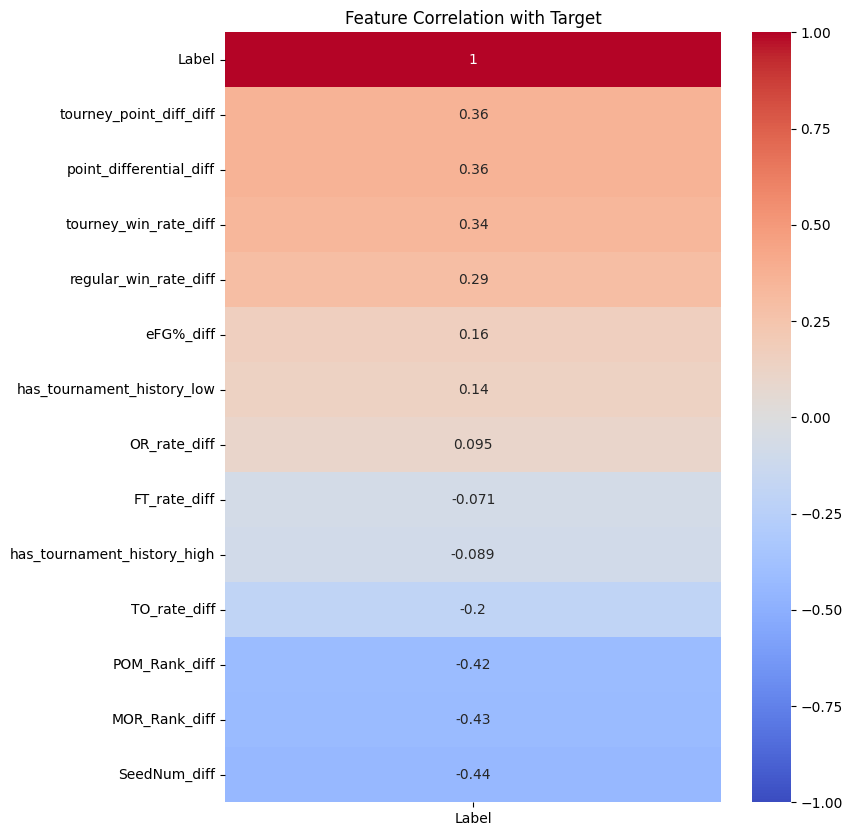

In [329]:
# feature importance
import seaborn as sns
import matplotlib.pyplot as plt

# Convert scaled array back to DataFrame
train_data = pd.DataFrame(X_train_scaled, columns=X_train.columns)

# Add the target column
train_data['Label'] = y_train.values

# Compute correlation
corr = train_data.corr()

plt.figure(figsize=(8, 10))
sns.heatmap(corr[['Label']].sort_values(by='Label', ascending=False), annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Feature Correlation with Target")
plt.show()

In [330]:
# variance calculation
training_features = X_train.copy()
# training_features = training_features.drop(columns={'has_tournament_history_high', 'has_tournament_history_low'})
training_features.var()

regular_win_rate_diff             0.021401
point_differential_diff          43.337781
eFG%_diff                         0.001521
TO_rate_diff                      0.000500
OR_rate_diff                      0.002571
FT_rate_diff                      0.002139
SeedNum_diff                     55.959369
MOR_Rank_diff                  5220.910614
POM_Rank_diff                  5050.533814
tourney_win_rate_diff             0.123104
tourney_point_diff_diff         128.367923
has_tournament_history_high       0.052631
has_tournament_history_low        0.067577
dtype: float64

In [331]:
coefficients = pd.Series(
    model.coef_[0],
    index=X.columns
).sort_values(key=abs, ascending=False)

print(coefficients)
print("\n")
(corr[['Label']].sort_values(by='Label', ascending=True))

SeedNum_diff                  -0.099316
MOR_Rank_diff                 -0.093827
POM_Rank_diff                 -0.090407
tourney_point_diff_diff        0.081907
tourney_win_rate_diff          0.078747
point_differential_diff        0.076758
regular_win_rate_diff          0.060182
TO_rate_diff                  -0.041036
has_tournament_history_low     0.031068
eFG%_diff                      0.030967
OR_rate_diff                   0.028609
FT_rate_diff                  -0.019785
has_tournament_history_high   -0.018575
dtype: float64




,Label
SeedNum_diff,-0.440154
MOR_Rank_diff,-0.427289
POM_Rank_diff,-0.421614
TO_rate_diff,-0.197344
has_tournament_history_high,-0.088726
FT_rate_diff,-0.070837
OR_rate_diff,0.095450
has_tournament_history_low,0.137293
eFG%_diff,0.163998
regular_win_rate_diff,0.292481


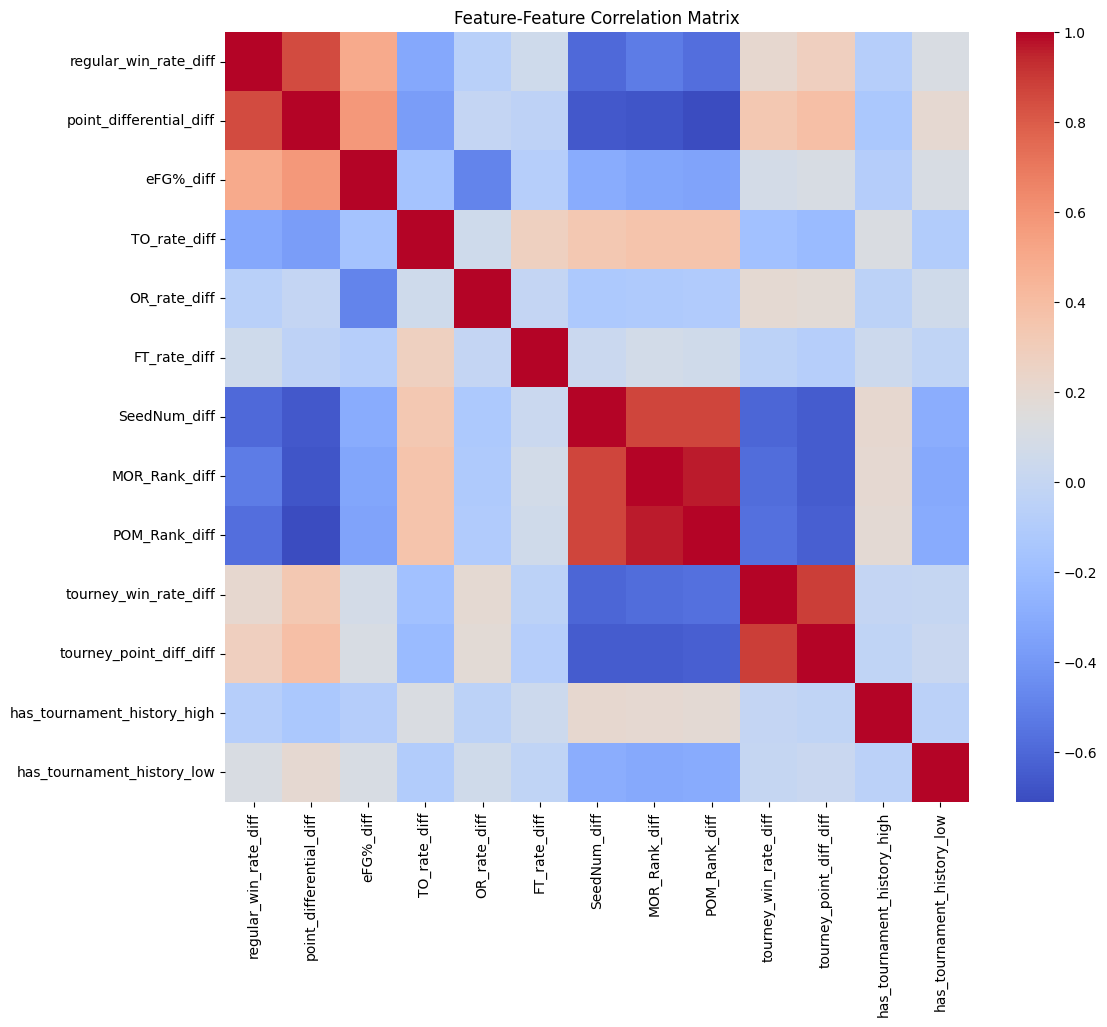

In [332]:

plt.figure(figsize=(12, 10))
corr = training_features.corr()
sns.heatmap(corr, cmap="coolwarm", annot=False)
plt.title("Feature-Feature Correlation Matrix")
plt.show()

In [333]:
corr

,regular_win_rate_diff,point_differential_diff,eFG%_diff,TO_rate_diff,OR_rate_diff,FT_rate_diff,SeedNum_diff,MOR_Rank_diff,POM_Rank_diff,tourney_win_rate_diff,tourney_point_diff_diff,has_tournament_history_high,has_tournament_history_low
regular_win_rate_diff,1.000000,0.848261,0.498532,-0.320469,-0.064178,0.052460,-0.591668,-0.523553,-0.571637,0.208578,0.283013,-0.080371,0.112857
point_differential_diff,0.848261,1.000000,0.576561,-0.374884,-0.007022,-0.040033,-0.663312,-0.673518,-0.710958,0.337423,0.391174,-0.135602,0.199000
eFG%_diff,0.498532,0.576561,1.000000,-0.169249,-0.488260,-0.079894,-0.302559,-0.333218,-0.345151,0.080489,0.108374,-0.082733,0.104601
TO_rate_diff,-0.320469,-0.374884,-0.169249,1.000000,0.055336,0.278173,0.337215,0.362543,0.361388,-0.180101,-0.216608,0.119580,-0.102312
OR_rate_diff,-0.064178,-0.007022,-0.488260,0.055336,1.000000,-0.006687,-0.123619,-0.110991,-0.104241,0.193314,0.179022,-0.048050,0.060383
FT_rate_diff,0.052460,-0.040033,-0.079894,0.278173,-0.006687,1.000000,0.029643,0.072960,0.059158,-0.044352,-0.077559,0.038299,-0.027703
SeedNum_diff,-0.591668,-0.663312,-0.302559,0.337215,-0.123619,0.029643,1.000000,0.867207,0.872099,-0.607169,-0.647585,0.207914,-0.291209
MOR_Rank_diff,-0.523553,-0.673518,-0.333218,0.362543,-0.110991,0.072960,0.867207,1.000000,0.966503,-0.579659,-0.644506,0.199150,-0.314192
POM_Rank_diff,-0.571637,-0.710958,-0.345151,0.361388,-0.104241,0.059158,0.872099,0.966503,1.000000,-0.569575,-0.635145,0.191024,-0.303877
tourney_win_rate_diff,0.208578,0.337423,0.080489,-0.180101,0.193314,-0.044352,-0.607169,-0.579659,-0.569575,1.000000,0.888078,-0.004654,-0.000271
